<h1>TAREA 2</h1>

<h2>A) Extracción y procesamiento de data</h2>

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime
import time

<h5>Función auxiliar para hacer peticiones a la API</h5>

In [4]:
def obtener_json_api(metodo, parametros=None):
    url_base = "https://codeforces.com/api/"
    url = url_base + metodo
    
    try:
        respuesta = requests.get(url, params=parametros)
        if respuesta.status_code == 200:
            datos = respuesta.json()
            if datos["status"] == "OK":
                return datos["result"]
            else:
                print(f"Error de API: {datos['comment']}")
                return None
        else:
            print(f"La petición falló con código: {respuesta.status_code}")
            return None
    except Exception as e:
        print(f"Error al realizar la petición: {e}")
        return None

<h3>PASO 1: Obtener la lista de concursos que cumplen los criterios</h3>

In [6]:
def obtener_concursos_filtrados():
    """Obtener concursos que coinciden con nuestros criterios."""
    print("⏳ Obteniendo lista de concursos...")
    todos_concursos = obtener_json_api("contest.list")
    
    if not todos_concursos:
        return []
    
    # Filtrado de concursos
    terminos_busqueda = ["Hello", "Round", "Good Bye"]
    concursos_filtrados = []
    
    for concurso in todos_concursos:
        if "startTimeSeconds" not in concurso:
            continue
            
        fecha_inicio = datetime.fromtimestamp(concurso["startTimeSeconds"])
        
        # Verificar si el concurso es de julio-diciembre 2024
        if (fecha_inicio.year == 2024 and 7 <= fecha_inicio.month <= 12):
            # Verificar si contiene alguno de los términos de búsqueda
            if any(termino in concurso["name"] for termino in terminos_busqueda):
                concursos_filtrados.append({
                    'id': concurso['id'],
                    'nombre': concurso['name'],
                    'fecha': fecha_inicio.strftime('%Y-%m-%d')
                })
    
    # Guardar resultados en JSON
    with open("concursos_filtrados.json", "w", encoding="utf-8") as f:
        json.dump(concursos_filtrados, f, ensure_ascii=False, indent=2)
    
    print(f" Se encontraron {len(concursos_filtrados)} concursos que cumplen los criterios")
    return concursos_filtrados

<h3>PASO 2: Mostrar los concursos filtrados</h3>

In [8]:
def mostrar_concursos(concursos):
    print(f" Concursos que cumplen con las condiciones: {len(concursos)}\n")
    for c in concursos:
        print(f" {c['id']} - {c['nombre']} ||| {c['fecha']}")

<h3>PASO 3: Extracción de datos de concurso</h3>

In [10]:
def procesar_concursos(concursos):
    # Lista para almacenar todos los DataFrames
    todas_submissions = []
    
    for concurso in concursos:
        ID_CONCURSO = concurso['id']
        print(f" Procesando concurso {ID_CONCURSO}: {concurso['nombre']}...")
        
        # Crear carpeta para guardar archivos
        CARPETA = str(ID_CONCURSO)
        os.makedirs(CARPETA, exist_ok=True)
        
        # 1. Obtener info del concurso y problemas
        standings_url_params = {
            "contestId": ID_CONCURSO,
            "from": 1,
            "count": 1000
        }
        standings = obtener_json_api("contest.standings", standings_url_params)
        
        if not standings:
            print(f" No se pudieron obtener datos de standings para el concurso {ID_CONCURSO}")
            continue
        
        # Standings - INFO DEL CONCURSO
        info_concurso = {
            'id_concurso': standings['contest']['id'],
            'nombre_concurso': standings['contest']['name'],
            'hora_inicio_concurso': datetime.fromtimestamp(standings['contest']['startTimeSeconds'])
        }
        pd.DataFrame([info_concurso]).to_csv(f"{CARPETA}/info_concurso.csv", index=False)
        
        # Standings - PROBLEMAS
        problemas = standings['problems']
        datos_problemas = []
        for p in problemas:
            datos_problemas.append({
                'problem_index': p['index'],
                'problem_name': p['name'],
                'rating': p.get('rating', None),
                'tags': ','.join(p.get('tags', []))
            })
        pd.DataFrame(datos_problemas).to_csv(f"{CARPETA}/problemas.csv", index=False)
        
        # 2. Obtener submissions
        submissions_url_params = {"contestId": ID_CONCURSO}
        submissions = obtener_json_api("contest.status", submissions_url_params)
        
        if not submissions:
            print(f" No se pudieron obtener submissions para el concurso {ID_CONCURSO}")
            continue
            
        # Procesar submissions
        datos_submissions = []
        for s in submissions:
            if 'author' in s and 'members' in s['author'] and s['author']['members']:
                datos_submission = {
                    'id_autor': s['author']['members'][0]['handle'],
                    'problem_index': s['problem']['index'],
                    'problem_name': s['problem']['name'],
                    'verdict': s.get('verdict', 'UNKNOWN'),
                    'runtime': s.get('timeConsumedMillis', None),
                    'memory': s.get('memoryConsumedBytes', None),
                    'language': s.get('programmingLanguage', None),
                    'relative_time_seconds': s.get('relativeTimeSeconds', None),
                    'timestamp': datetime.fromtimestamp(s['creationTimeSeconds']),
                    'id_concurso': ID_CONCURSO,
                    'nombre_concurso': info_concurso['nombre_concurso'],
                    'hora_inicio_concurso': info_concurso['hora_inicio_concurso']
                }
                datos_submissions.append(datos_submission)
        
        # 3. Obtener cambios de rating
        rating_changes_url_params = {"contestId": ID_CONCURSO}
        
        try:
            cambios_rating = obtener_json_api("contest.ratingChanges", rating_changes_url_params)
            datos_cambios_rating = []
            
            if cambios_rating:
                for cambio in cambios_rating:
                    datos_cambios_rating.append({
                        'id_autor': cambio['handle'],
                        'old_rating': cambio['oldRating'],
                        'new_rating': cambio['newRating'],
                        'rating_change': cambio['newRating'] - cambio['oldRating'],
                        'id_concurso': ID_CONCURSO
                    })
                pd.DataFrame(datos_cambios_rating).to_csv(f"{CARPETA}/cambios_rating.csv", index=False)
            
                # Crear DataFrame de submissions con datos de rating
                df_submissions = pd.DataFrame(datos_submissions)
                df_rating = pd.DataFrame(datos_cambios_rating)
                
                if not df_submissions.empty and not df_rating.empty:
                    df_merged = pd.merge(df_submissions, df_rating, on=['id_autor', 'id_concurso'], how='left')
                    # Guardar datos combinados
                    df_merged.to_csv(f"{CARPETA}/concurso_{ID_CONCURSO}_completo.csv", index=False)
                    todas_submissions.append(df_merged)
                else:
                    df_submissions.to_csv(f"{CARPETA}/concurso_{ID_CONCURSO}_completo.csv", index=False)
                    todas_submissions.append(df_submissions)
            else:
                print(f" Sin cambios de rating para concurso {ID_CONCURSO}")
                df_submissions = pd.DataFrame(datos_submissions)
                df_submissions['old_rating'] = None
                df_submissions['new_rating'] = None
                df_submissions['rating_change'] = None
                df_submissions.to_csv(f"{CARPETA}/concurso_{ID_CONCURSO}_completo.csv", index=False)
                todas_submissions.append(df_submissions)
                
        except Exception as e:
            print(f" Error al obtener cambios de rating para concurso {ID_CONCURSO}: {e}")
            df_submissions = pd.DataFrame(datos_submissions)
            df_submissions['old_rating'] = None
            df_submissions['new_rating'] = None
            df_submissions['rating_change'] = None
            df_submissions.to_csv(f"{CARPETA}/concurso_{ID_CONCURSO}_completo.csv", index=False)
            todas_submissions.append(df_submissions)
        
        # Pausa para evitar límites de tasa
        time.sleep(1)
        print(f"✅ Procesado concurso {ID_CONCURSO}")
    
    return todas_submissions


<h3>PASO 4: Unir todos los datos en un solo DataFrame</h3>

In [12]:
def unir_datos(dataframes):
    if not dataframes:
        print("⚠️ No hay datos para unir")
        return None
        
    df_completo = pd.concat(dataframes, ignore_index=True)
    df_completo.to_csv("todos_los_concursos.csv", index=False)
    print("✅ Archivo combinado guardado como 'todos_los_concursos.csv'")
    return df_completo


<h3>PASO 5: Limpiar y transformar datos</h3>

In [14]:
def limpiar_transformar_datos(df):
    if df is None or df.empty:
        print("⚠️ No hay datos para procesar")
        return None
        
    print("⏳ Limpiando y transformando datos...")
    
    # Copia del DataFrame original
    df_limpio = df.copy()
    
    # Asegurar que las columnas de fecha son de tipo datetime
    df_limpio['timestamp'] = pd.to_datetime(df_limpio['timestamp'], errors='coerce')
    df_limpio['hora_inicio_concurso'] = pd.to_datetime(df_limpio['hora_inicio_concurso'], errors='coerce')
    
    # Filtrar por fecha (solo julio a diciembre de 2024)
    fecha_inicio = pd.Timestamp("2024-07-01")
    fecha_fin = pd.Timestamp("2024-12-31 23:59:59")
    df_limpio = df_limpio[(df_limpio['timestamp'] >= fecha_inicio) & (df_limpio['timestamp'] <= fecha_fin)]
    
    # Crear variables derivadas
    # Tiempo de respuesta en minutos desde inicio del concurso
    df_limpio['tiempo_respuesta_min'] = df_limpio['relative_time_seconds'] / 60
    
    # Hora del día de la submission (0-23)
    df_limpio['hora_submission'] = df_limpio['timestamp'].dt.hour
    
    # Rating alcanzado después de la submission
    df_limpio['rating_alcanzado'] = df_limpio['old_rating'] + df_limpio['rating_change']
    
    # Datos para análisis de rating
    df_con_rating = df_limpio.dropna(subset=['old_rating', 'new_rating', 'rating_change'])
    
    # Crear categorías de tiempo para análisis
    bins = [0, 5, 10, 15, 20, 30, 45, 60, 90, 120, 1000]
    labels = ['0-5', '5-10', '10-15', '15-20', '20-30', '30-45', '45-60', '60-90', '90-120', '120+']
    df_limpio['rango_tiempo'] = pd.cut(df_limpio['tiempo_respuesta_min'], bins=bins, labels=labels, right=False)
    
    # Datos para gráfico de densidad: máximo rating por usuario
    df_ratings = df_limpio[['id_autor', 'new_rating']].dropna()
    max_rating_por_usuario = (
        df_ratings
        .groupby('id_autor')['new_rating']
        .max()
        .reset_index()
        .rename(columns={'new_rating': 'max_rating'})
    )
    
    print(f"✅ Limpieza completada. Registros resultantes: {len(df_limpio)}")
    print(f"Registros con rating válido: {len(df_con_rating)}")
    
    return {
        'df_completo': df_limpio,
        'df_con_rating': df_con_rating,
        'max_rating_usuarios': max_rating_por_usuario
    }

# Ejecución principal - obtenemos y procesamos los datos
concursos = obtener_concursos_filtrados()
mostrar_concursos(concursos)
dataframes = procesar_concursos(concursos)
df_todos = unir_datos(dataframes)
datos_procesados = limpiar_transformar_datos(df_todos)

# Verificamos que tenemos datos para analizar
if datos_procesados is None:
    print("⚠️ No hay datos disponibles para análisis")
else:
    # Guardamos los DataFrames principales para análisis
    df = datos_procesados['df_completo']
    df_rating = datos_procesados['df_con_rating']
    max_rating = datos_procesados['max_rating_usuarios']
    
    print("\n📊 Datos listos para análisis gráfico")
    print(f"Dimensiones del DataFrame principal: {df.shape}")
    print("\n🔍 Primeras filas del DataFrame:")
    print(df.head())

⏳ Obteniendo lista de concursos...
 Se encontraron 57 concursos que cumplen los criterios
 Concursos que cumplen con las condiciones: 57

 2053 - Good Bye 2024: 2025 is NEAR ||| 2024-12-28
 2043 - Educational Codeforces Round 173 (Rated for Div. 2) ||| 2024-12-24
 2051 - Codeforces Round 995 (Div. 3) ||| 2024-12-22
 2049 - Codeforces Round 994 (Div. 2) ||| 2024-12-20
 2048 - Codeforces Global Round 28 ||| 2024-12-19
 2044 - Codeforces Round 993 (Div. 4) ||| 2024-12-15
 2040 - Codeforces Round 992 (Div. 2) ||| 2024-12-08
 2050 - Codeforces Round 991 (Div. 3) ||| 2024-12-05
 2046 - Codeforces Round 990 (Div. 1) ||| 2024-12-03
 2047 - Codeforces Round 990 (Div. 2) ||| 2024-12-03
 2042 - Educational Codeforces Round 172 (Rated for Div. 2) ||| 2024-12-02
 2034 - Rayan Programming Contest 2024 - Selection (Codeforces Round 989, Div. 1 + Div. 2) ||| 2024-11-30
 2039 - CodeTON Round 9 (Div. 1 + Div. 2, Rated, Prizes!) ||| 2024-11-23
 2037 - Codeforces Round 988 (Div. 3) ||| 2024-11-17
 2031 - 

C:\Users\user\AppData\Local\Temp\ipykernel_22660\2127846915.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_completo = pd.concat(dataframes, ignore_index=True)


✅ Archivo combinado guardado como 'todos_los_concursos.csv'
⏳ Limpiando y transformando datos...
✅ Limpieza completada. Registros resultantes: 9428017
Registros con rating válido: 5328768

📊 Datos listos para análisis gráfico
Dimensiones del DataFrame principal: (9428017, 19)

🔍 Primeras filas del DataFrame:
            id_autor problem_index                        problem_name  \
37524  codecommander             A                    Tender Carpenter   
37525            363             B           Outstanding Impressionist   
37526   starfish_can            I1  Affectionate Arrays (Easy Version)   
37527        kavascg             D          Refined Product Optimality   
37528    zhx20081129             D          Refined Product Optimality   

                   verdict  runtime     memory                  language  \
37524                   OK       46          0          C++17 (GCC 7-32)   
37525  TIME_LIMIT_EXCEEDED     1000          0  C++23 (GCC 14-64, msys2)   
37526        RUNT

<h2>B) EXPLICACIÓN</h2>

### Descripción del Dataset

#### API Endpoints Utilizados
Para este análisis se utilizaron los siguientes endpoints:
- `api/user/data`: Para obtener información sobre los usuarios
- `api/submissions/data`: Para obtener datos sobre las presentaciones de respuestas
- `api/ratings/data`: Para obtener información de calificaciones

#### Estructura del Dataset
El dataset contiene información sobre usuarios, sus respuestas a preguntas y sus calificaciones. Los datos están organizados en un formato JSON y contienen información temporal, características de los usuarios y métricas de desempeño.

#### Explicación de Variables
- `user_id`: Identificador único para cada usuario
- `submission_id`: Identificador único para cada presentación de respuesta
- `timestamp`: Momento en que se presentó la respuesta (formato Unix timestamp)
- `language`: Lenguaje de programación utilizado en la respuesta
- `rating`: Calificación del usuario antes de la presentación
- `finished`: Indicador booleano de si la pregunta fue completada
- `time_to_answer`: Tiempo tomado para responder (segundos)
- `relative_time`: Tiempo relativo desde el inicio de la sesión


<h2>C) PROCESAMIENTO</h2>

In [14]:
import pandas as pd
import numpy as np

# Cargar el archivo desde la misma carpeta
df_final_hw2 = pd.read_csv("todos_los_concursos.csv")

# Eliminar valores nulos críticos
df_final_hw2 = df_final_hw2.dropna(subset=["timestamp", "relative_time_seconds"])

# Convertir columnas de fecha y hora
df_final_hw2["timestamp"] = pd.to_datetime(df_final_hw2["timestamp"])
df_final_hw2["hora_inicio_concurso"] = pd.to_datetime(df_final_hw2["hora_inicio_concurso"])

# Variables derivadas
df_final_hw2["finished_n"] = (df_final_hw2["verdict"] == "OK").astype(int)
df_final_hw2["relative_time_n"] = df_final_hw2["relative_time_seconds"] / 60

# Calcular tiempo entre envíos
df_final_hw2 = df_final_hw2.sort_values(["id_autor", "relative_time_seconds"])
df_final_hw2["time_to_answer_n"] = (
    df_final_hw2.groupby("id_autor")["relative_time_n"].diff().fillna(0)
)

# Calcular rating alcanzado
df_final_hw2["rating_achieved"] = (
    df_final_hw2["old_rating"] + df_final_hw2["rating_change"]
)


<h2>D) VISUALIZACIÓN</h2>

<h3>Gráfico 1</h3>

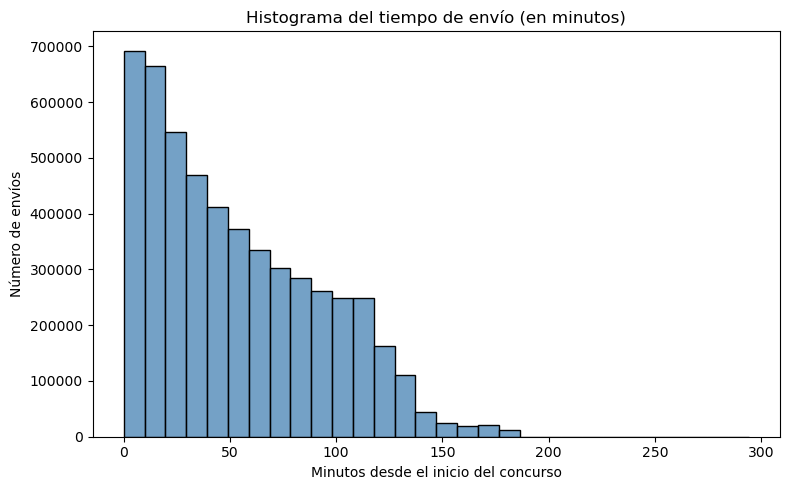

In [21]:
# Filtrar valores razonables (por ejemplo, menos de 300 minutos = 5 horas)
df_filtered = df_final_hw2[df_final_hw2["relative_time_n"] < 300]


plt.figure(figsize=(8, 5))
sns.histplot(df_filtered["relative_time_n"], bins=30, kde=False, color="steelblue")
plt.title("Histograma del tiempo de envío (en minutos)")
plt.xlabel("Minutos desde el inicio del concurso")
plt.ylabel("Número de envíos")
plt.tight_layout()
plt.show()


<h3>Gráfico 2</h3>

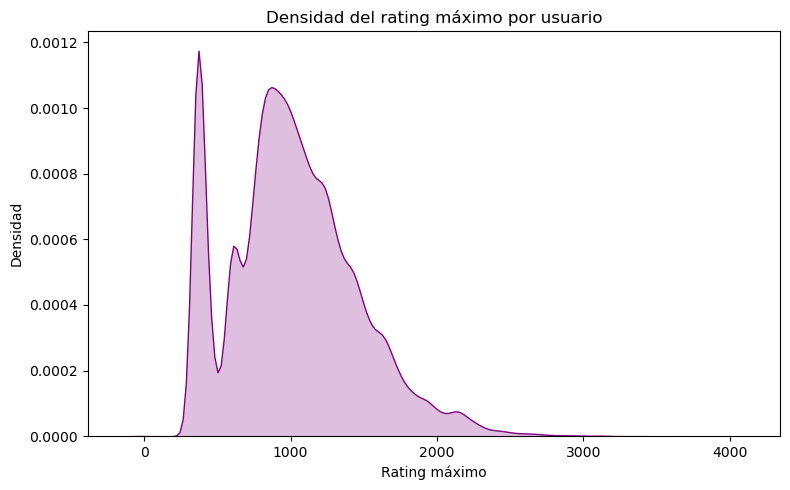

In [16]:
max_rating = df_final_hw2.groupby("id_autor")["new_rating"].max().dropna()

plt.figure(figsize=(8, 5))
sns.kdeplot(max_rating, fill=True, color="purple")
plt.title("Densidad del rating máximo por usuario")
plt.xlabel("Rating máximo")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()


<h3>Gráfico 3</h3>

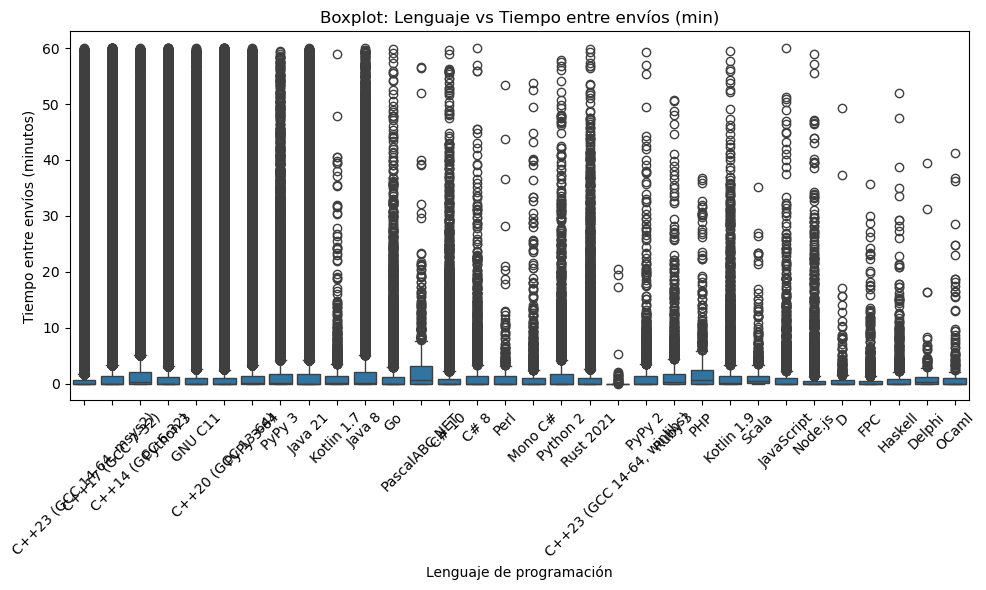

In [22]:
df_box = df_final_hw2[(df_final_hw2["time_to_answer_n"] < 60) & (df_final_hw2["time_to_answer_n"].notna())]
top_langs = df_box["language"].value_counts()
top_langs = top_langs[top_langs > 100].index
df_box = df_box[df_box["language"].isin(top_langs)]
plt.figure(figsize=(10, 6))
sns.boxplot(x="language", y="time_to_answer_n", data=df_box)
plt.xticks(rotation=45)
plt.title("Boxplot: Lenguaje vs Tiempo entre envíos (min)")
plt.xlabel("Lenguaje de programación")
plt.ylabel("Tiempo entre envíos (minutos)")
plt.tight_layout()
plt.show()


<h3>Gráfico 4</h3>

C:\Users\user\AppData\Local\Temp\ipykernel_14240\2020350791.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bins["bin"] = pd.qcut(df_bins["rating_achieved"], q=20, duplicates='drop')
C:\Users\user\AppData\Local\Temp\ipykernel_14240\2020350791.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_bins.groupby("bin")["time_to_answer_n"].mean()


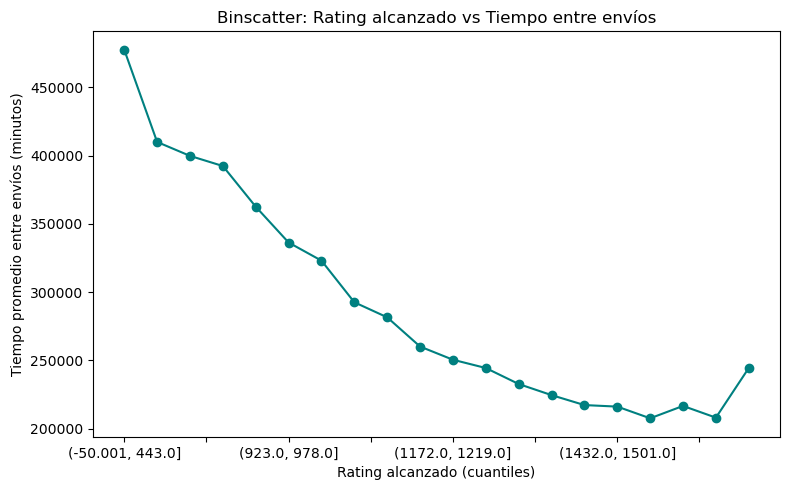

In [19]:
df_bins = df_final_hw2.dropna(subset=["rating_achieved", "time_to_answer_n"])
df_bins["bin"] = pd.qcut(df_bins["rating_achieved"], q=20, duplicates='drop')

plt.figure(figsize=(8, 5))
df_grouped = df_bins.groupby("bin")["time_to_answer_n"].mean()
df_grouped.plot(marker="o", linestyle="-", color="teal")
plt.title("Binscatter: Rating alcanzado vs Tiempo entre envíos")
plt.xlabel("Rating alcanzado (cuantiles)")
plt.ylabel("Tiempo promedio entre envíos (minutos)")
plt.tight_layout()
plt.show()


<h3>Gráfico 5</h3>

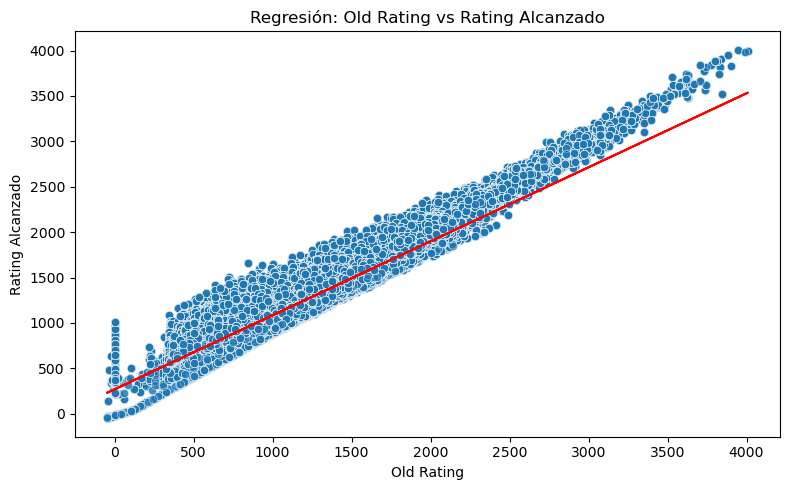

In [23]:
import statsmodels.api as sm

df_reg = df_final_hw2.dropna(subset=["old_rating", "rating_achieved"])
X = sm.add_constant(df_reg["old_rating"])
model = sm.OLS(df_reg["rating_achieved"], X).fit()

# Gráfico con línea de regresión
plt.figure(figsize=(8, 5))
sns.scatterplot(x="old_rating", y="rating_achieved", data=df_reg, alpha=0.6)
plt.plot(df_reg["old_rating"], model.predict(X), color="red")
plt.title("Regresión: Old Rating vs Rating Alcanzado")
plt.xlabel("Old Rating")
plt.ylabel("Rating Alcanzado")
plt.tight_layout()
plt.show()
